In [1]:
import pandas as pd

# Dataset de encuestas
df = pd.DataFrame({
    'cliente_id': [1, 2, 3, 4, 5],
    'departamento': ['Ventas', 'Soporte', 'Ventas', 'Producto', 'Soporte'],
    'compra_hecha': [True, False, True, True, False]
})

# Conjuntos de departamentos
departamentos_totales = set(df['departamento'])  # {Ventas, Soporte, Producto}
departamentos_ventas = set(df[df['departamento'] == 'Ventas']['departamento'])

# Clientes que compraron
clientes_compradores = set(df[df['compra_hecha']]['cliente_id'])  # {1, 3, 4}

# Clientes que NO compraron
clientes_no_compradores = set(df[~df['compra_hecha']]['cliente_id'])  # {2, 5}

# Diferencia: clientes totales - que compraron
total_clientes = set(df['cliente_id'])
clientes_para_seguimiento = total_clientes - clientes_compradores

print(f"Departamentos: {departamentos_totales}")
print(f"Clientes a seguimiento: {clientes_para_seguimiento}")

Departamentos: {'Producto', 'Soporte', 'Ventas'}
Clientes a seguimiento: {2, 5}


In [12]:
departamento_ventas = df.query('departamento == "Ventas"')
clientes_compradores = df.query('compra_hecha == True')
clientes_no_compradores = df.query('compra_hecha == False')

# Validación de quienes no compraron
total_clientes = df['cliente_id']
clientes_para_seguimiento = total_clientes[~total_clientes.isin(clientes_compradores['cliente_id'])]

print(departamento_ventas)
print(clientes_compradores)
print(clientes_no_compradores)
print(clientes_para_seguimiento)

   cliente_id departamento  compra_hecha
0           1       Ventas          True
2           3       Ventas          True
   cliente_id departamento  compra_hecha
0           1       Ventas          True
2           3       Ventas          True
3           4     Producto          True
   cliente_id departamento  compra_hecha
1           2      Soporte         False
4           5      Soporte         False
0    1
2    3
3    4
Name: cliente_id, dtype: int64


In [13]:
# Ejemplo 1: Función simple
def f(x):
    """
    f: ℝ → ℝ
    Mapea cualquier real a su valor absoluto
    """
    return abs(x)

print(f(-5))  # 5
print(f(3.5))  # 3.5

# Ejemplo 2: Función de ℕ → ℝ
def factorial(n):
    """
    f: ℕ → ℝ
    Calcula el factorial de un número natural
    """
    if n < 0:
        raise ValueError("n debe ser natural")
    if n == 0 or n == 1:
        return 1
    return n * factorial(n - 1)

print(factorial(5))  # 120

# Ejemplo 3: Función de ℝ → ℝ⁺ (CSAT normalizado)
def normalizar_csat(puntuacion):
    """
    f: ℝ → ℝ⁺
    Transforma CSAT (1-10) a rango (0-1)

    Dominio: ℝ (cualquier número real)
    Rango real: (0, 1) (salida solo positivos)
    """
    if puntuacion < 1 or puntuacion > 10:
        raise ValueError("CSAT debe estar entre 1 y 10")
    return (puntuacion - 1) / 9

print(normalizar_csat(5))  # 0.4444...

5
3.5
120
0.4444444444444444


Función: f(x) = -0.3015x + 8.2293
Dominio: x ∈ ℝ (cualquier tiempo)
Rango: f(x) ∈ ℝ (cualquier satisfacción predicha)

f(6) = 6.42


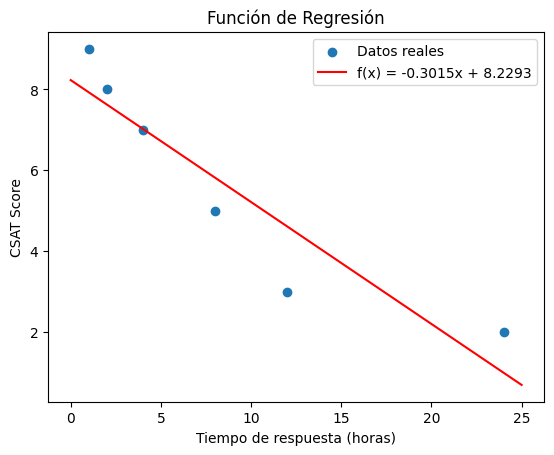

In [14]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Dataset: Tiempo de respuesta vs CSAT
datos = pd.DataFrame({
    'tiempo_respuesta': [1, 2, 4, 8, 12, 24],
    'csat_score': [9, 8, 7, 5, 3, 2]
})

# Entrenar modelo
X = datos[['tiempo_respuesta']].values
y = datos['csat_score'].values

modelo = LinearRegression()
modelo.fit(X, y)

# Obtener parámetros
m = modelo.coef_[0]  # pendiente
b = modelo.intercept_  # intercepto

print(f"Función: f(x) = {m:.4f}x + {b:.4f}")
print(f"Dominio: x ∈ ℝ (cualquier tiempo)")
print(f"Rango: f(x) ∈ ℝ (cualquier satisfacción predicha)")

# Predicción (aplicar la función)
tiempo_nuevo = 6
prediccion = modelo.predict([[tiempo_nuevo]])
print(f"\nf({tiempo_nuevo}) = {prediccion[0]:.2f}")

# Visualizar
plt.scatter(X, y, label='Datos reales')
x_line = np.linspace(0, 25, 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, 'r-', label=f'f(x) = {m:.4f}x + {b:.4f}')
plt.xlabel('Tiempo de respuesta (horas)')
plt.ylabel('CSAT Score')
plt.legend()
plt.title('Función de Regresión')
plt.show()